<a href="{{ colab_base_laboratorios }}/Laboratorio_08_clasificacionLogistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 8: Clasificacion Logística

Si deseamos clasificar algún tipo de imagen, resultado en campos medicos, astrofisicos se pueden aplicar algoritmos de clasificación. En particular en esta sesión se estudia los principios basicos de  regresión logística para aplicarla a los  modelos de clasificación.

Supongamos que queremos clasificar un sistema que tiene dos tipos posibles (los llamaremos los tipos 0 y 1) basado en dos características (correspondiente a dos variables X1 y X2) :



In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification,make_circles
import numpy as np

Text(0, 0.5, 'X_2')

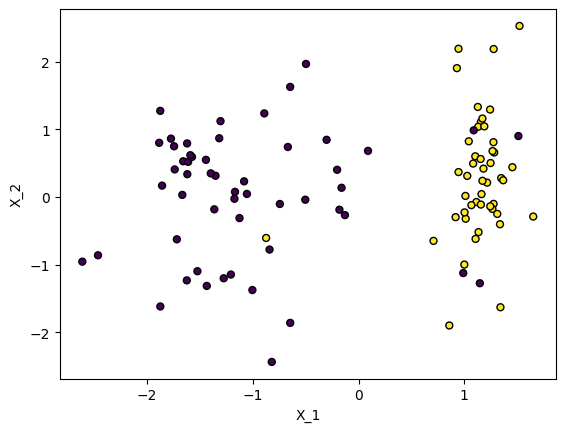

In [3]:
#Vamos a crear los datos de dos tipos introduciendo un porcentaje de
#valores con "ruido" (flip_y). Pruebe a cambiar el valor
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.xlabel("X_1")
plt.ylabel("X_2")

En este caso cada color representa los objetos tipos 0 y tipo 1. Para aplicar un algoritmo de clasificación relacionaremos el valor $h_{\theta}(X^{i}=x)$ con la probabilidad de obtener un valor de y dado un x parametrizado por $\theta$, $P(y=1|X=x;\theta)$, asi :

 $h_{\theta}(X^{i}=x) = P(y=1|X^{i};\theta) $

 Tenemos que:  $P(y=1|x;\theta)+P(y=0|x;\theta) = 1$

Si tenemos muestra equiprobables, podemos definir lo siguiente  para P :

- $P<0.5$ se obtienen los objetos tipo 0
- $P \geq 0.5$ se obtienen los objetos tipo 1

Podemos establecer un clasificador de los  sistemas basado en las probabilidades a partir de un clasificador logístico:


\begin{equation}
f(z)=\frac{1}{(1+e^{-z})}
\end{equation}
Cuya derivada es :

\begin{equation}
f'(z)=f(z)(1-f(z))
\end{equation}



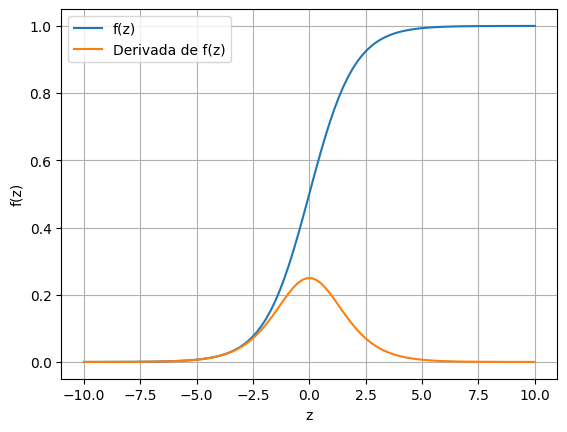

In [4]:
f = lambda x: 1/(1+np.exp(-x))
fp = lambda x: f(x)*(1-f(x))
z=np.linspace(-10, 10, 100)

plt.figure()
plt.plot(z,f(z), label="f(z)")
plt.plot(z,fp(z), label="Derivada de f(z)")
plt.ylabel("f(z)")
plt.xlabel("z")
plt.grid()
plt.legend()

- Para valores de $z< 0.0$ la regresión logistica clasica objetos tipo 0, siendo $f(z)<0.5$
- Para valores de $z\geq 0.0$ la regresión logística clasica objetos tipo 1 siendo $f(z) \geq  0.5$

¿Cual es la probabilidad de que dado un hyperplano, los valores de un hyperlado sean objetos tipo 0 o tipo 1?

Aplicando la regresión logistica, a las regresiones multivariadas estudiadas en la sesiones anteriores, tenemos que el argumento $z=\Theta^{T} X$, así:


\begin{equation}
h_{\theta}(X)=\frac{1}{(1+e^{-\Theta^T X})}
\end{equation}


- Se cumple que para los valores del hyperplano  $\Theta^T X\geq 0.0$, $y = 1$
- Se cumple que para  $\Theta^T X < 0.0$ , $y = 0$


Las condiciones anteriores permiten definir fronteras de desicion entre los datos a clasificar. Para los datos dados arriba, se puede establecer el siguiente clasificador.


$h_\theta(x) = g(\theta_0+\theta_1 x_1+\theta_2 x_2 ) $.

Una clasificación del dataset nos sugiere que la frontera para este dataset es:

$\theta_0+\theta_1 x_1+\theta_2 x_2 \geq 0.0$

Si por algun metodo encontramos que los parametros $\Theta$ entonces podemos definir la frontera de clasifiación. Como ejemplo supongamos que encontramos los siguientes parametros $\Theta=[3.0, -20, 1.0]$

Ecnontrar la ecuacion de la recta y mejorar la parametrizacion

$3-20x1+x2=0$

$x_2= 20 x_1 - 3$

In [5]:
x1 = np.linspace(0, 0.29, 100)
x2 = 20*x1-3

Text(0, 0.5, 'X_2')

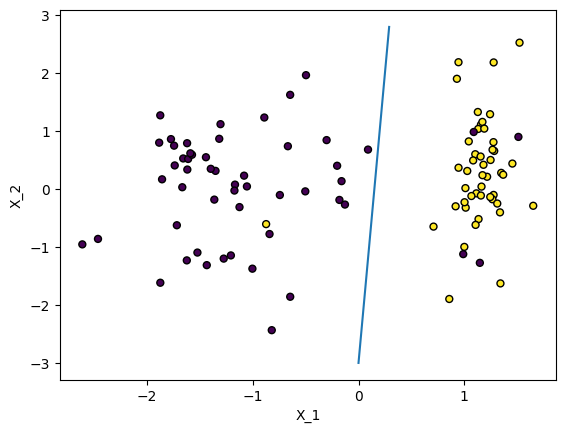

In [6]:
X1, Y1 = make_classification(
    n_features = 2, n_redundant = 0, n_informative=1, n_clusters_per_class=1,
    random_state = 1, class_sep=1.2, flip_y = 0.15)
plt.figure()
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.plot(x1, x2)
plt.xlabel("X_1")
plt.ylabel("X_2")

TODO: revisar signo de $\Theta^T X$ en la exponencial

Fronteras no lineal también puede ser consideradas, para ello se puede definir  $\Theta^T X$ como funcion de un polinomio, por ejemplo

$\Theta^T X =  \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2$

\begin{equation}
h_\theta(X) =  \frac{1}{1+e^-({\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2)}}
\end{equation}

La frontera de desición en este caso esta determinada por:

$\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_1
2^2 \geq 0$
para obtener un clasificador con valores de y = 1.

Para este mismo caso, supongamos que tenmos la siguiente distribución de datos, ¿Cuál es el mejor elección de parámetros $\Theta$ que permite clasificar los datos siguientes:







(np.float64(-1.12244940477901),
 np.float64(1.1839643638442499),
 np.float64(-1.2696420440360447),
 np.float64(1.185918477713659))

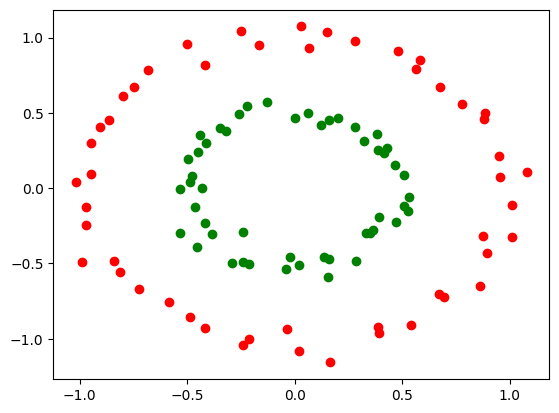

In [7]:
X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1
f, ax = plt.subplots()
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")
plt.axis("tight")

Analizando el conjunto de datos, se puede observar que la frontera es la de una circunferencia con centro en (0, 0) y radio de 0.7 aproxidamente,  asi nuestra elección de parámetros para el polinomio ejemplicado en la celda anterior ($\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 +\theta_4 x_2^2 \geq 0$ ) es:


$\Theta^T = [-0.7,0, 0, 1,1 ] $

Reemplando tenemos que:

$-0.7+x_1^2+x_2^2 \geq 0$

$x_1^2+x_2^2 \geq 0.7$

Text(0, 0.5, 'X_2')

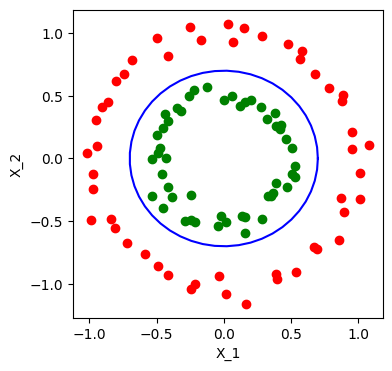

In [8]:
#Por motivos graficos transformemos la ecuación anterior parametrizada
#por theta

alpha = np.linspace(0, 2*np.pi)
x1=0.7*np.cos(alpha)
x2=0.7*np.sin(alpha)

X, y = make_circles(
    n_samples=100, factor=0.5, noise=0.05, random_state=0)
red = y == 0
green = y == 1

f, ax = plt.subplots(figsize=(4,4))
ax.scatter(X[red, 0], X[red, 1], c="r")
ax.scatter(X[green, 0], X[green, 1], c="g")

plt.plot(x1, x2,"b-")
plt.axis("tight")
plt.xlabel("X_1")
plt.ylabel("X_2")

De forma general, ¿Cómo pueden ser elegidos los valores de $\Theta$?.



Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T (X)}}
\end{equation}



Para ello, podemos definir la función de coste como :


\begin{equation}
J = \left \{
  \begin{array}{ c l }
    -\log h(x) & \quad \textrm{if } y = 1 \\
    -\log (1-h(x))  & \quad \textrm{if } y = 0 \\
  \end{array}
\right.
\end{equation}



Resumida en la siguiente expresión:


$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

Esta función de coste permite establecer el mejor clasificadose para la regresión logistica de acuerdo a la teoría de probabilidad. Se garantiza que cuando $P(y=1|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=0|x,\theta)$, analogamente, se cumple que cuando $P(y=0|x,\theta)$ se cumple la función de coste se minimiza, penalizando los valores que sean iguales a $P(y=1|x,\theta)$.
La metrica empleada para la regresión lineal no es recomedada en este caso, dado que la funcion de coste puede presentar múltiples minimos que dificultan la minimizacion  a través de algunas de las técnicas empleadas. Una justificación adicional para la métrica  es dada mas adelante segun la teoria de la probabilidad.

Se deja como tarea motrar que:

\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)}
\end{equation}

Para la demostración, muestre que:
- $f(z)=\frac{1}{1+e^{-z}} = f(z)(1-f(z))$
- $\frac{\partial h_{\theta}}{\partial \theta_j } = h_{\theta}(X^{(i)})(1-h_{\theta}(X^{(i)}))X_j^{(i)}$


La derivada permite aplicar el gradiente descendente para minimizar nuestra función de coste asi,  nuestro algoritmo de minimizacion permite encontrar los valores de $\theta$ despues de un conjunto determinado de itereaciones.

$\theta_j: \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$


Otros metodos de minizacion podrian ser aplicados, tales como:


[Gradiente conjugado ](https://es.wikipedia.org/wiki/M%C3%A9todo_del_gradiente_conjugado#:~:text=En%20matem%C3%A1tica%2C%20el%20m%C3%A9todo%20del,son%20sim%C3%A9tricas%20y%20definidas%20positivas.&text=Varios%20m%C3%A9todos%20del%20gradiente%20conjugado,de%20las%20ecuaciones%20no%20lineales)

[BFGS](https://en.wikipedia.org/wiki/Broyden%E2%80%93Fletcher%E2%80%93Goldfarb%E2%80%93Shanno_algorithm)


[L-BGFS](https://en.wikipedia.org/wiki/Limited-memory_BFGS)

[Newton-Rhapson](https://en.wikipedia.org/wiki/Newton%27s_method)


# Interpretación probabilística


¿Qué tan adeacuado es la elección de $J(\theta)$  para el modelo de regresion logistica?



\begin{equation}
P(y=1|x;\theta)= h_{\theta}(X^{(i)})
\end{equation}

\begin{equation}
P(y=0|x;\theta)= 1-h_{\theta}(X^{(i)})
\end{equation}



\begin{equation}
P(y|x;\theta)=[h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

Asumiendo que los datos de entrenamiento son independientes:

$\cal{L}(\theta)=p(\vec{y}|x, \theta)$

\begin{equation}
\cal{L}(\theta)=\prod_{i=1}^{m} [h_{\theta}(X^{(i)})]^{y}[1-h_{\theta}(X^{(i)})]^{1-y}
\end{equation}

tomando el logaritmo:


\begin{equation}
\log \cal{L}(\theta)= \sum_{i=1}^{m} y \log h_{\theta}(X^{(i)}) + (1-y)\log(1-h_{\theta}(X^{(i)}))
\end{equation}

Los datos a considerar son los mas probables es decir que para encontrar los valores de $\theta$ que nos garantizan la maxima probabilidad es necesario maximar la función anterior. Despues de realizar los calculos se puede mostrar la ecuación dada para el gradiente de la función de coste.



En conclusión se cumple que:

Para todo el conjunto de datos, tenemos que:

Sea $\Theta^T = [\theta_0,\theta_1,\theta_2,...,\theta_n]$ una matrix $1 \times (n+1)$ y  


\begin{equation}
X =
\begin{bmatrix}
1& 1 & 1 & .&.&.&1\\
x_1^{(1)}&x_1^{(2)} & x_1^{(3)} & .&.&.&x_1^{(m)}\\
.&. & . &.&.&.& .\\
.&. & . & .&.&.&.\\
.&. & . & .&.&.&.\\
x_n^{(1)}&x_n^{(2)} & x_n^{(3)} & .&.&.&x_n^{(m)}\\
\end{bmatrix}_{(n+1) \times m}
\end{equation}


\begin{equation}
h_\theta (x)= \frac{1}{1+e^{\Theta ^T X}}
\end{equation}



- Función de coste
$ J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right]$

- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)}
\end{equation}





# Regularización


## Regresion Lineal
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m}\sum_{j=1}^{n} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{1}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)}
\end{equation}



### Normal equation
\begin{equation}
\theta=(X^TX\lambda L)^{-1} X^T y
\end{equation}

\begin{equation}
\lambda=\begin{bmatrix}
0 & 0 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 1 \\
\end{bmatrix}
\end{equation}

Las dimensiones de $[\lambda]=(\mathrm{n+1}) \times (\mathrm{n+1})$



## Regresion Logistica
Disminuir la complejidad del algoritmo




- Función de coste
\begin{equation}
J (\Theta) =\frac{1}{m} \sum_{i=1}^{m} \left[-y\log (h_{\theta}(X ^ {i})) - (1-y)\log (1-h_{\theta}(X^{i})) \right] + \frac{\lambda}{2m}\sum_{j=1}^{n} \theta_j^2
\end{equation}



- Derivada de la funcion de coste
\begin{equation}
\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}[y^{(i)}-h_\theta X^{(i)}] X_j^{(i)} + \frac{\lambda}{m}\sum_{j=1}^{n} \theta_j
\end{equation}


El gradiente descendente puede ser escrito como:


\begin{equation}
\theta_j := \theta_j\left(1-\alpha \frac{\lambda}{m} \right) - \frac{1}{m}\sum_{i=1}^{m}[h_\theta X^{(i)}- y^{(i)}] X_j^{(i)}
\end{equation}



# Tomar el [iris dataset](https://en.wikipedia.org/wiki/Iris_flower_data_set) desde sklearn:

```
from sklearn import datasets

iris = datasets.load_iris()
```
- Realizar la clasifición de las tres clases  a traves de una regresión logística  y realizar multiclasicación, para ello considere lo siguiente:

Si en un dataset existen más de 2 clases, $y={0, 1, 2, 3, ...}$ se debe construir una multiclasificación, una contra todos, la estrategia sugerida es la siguiente.

Sea A, B, C las tres clases. Para estos valores definir:

1. Definir la clase A como la clase 0 y todas las otras B, C como la clase 1
2. Encontrar el valor $h_\theta(X) = P(y=A|x;\theta)$
3. Definir la clase B como la clase 0 y todas las otras A, C como la clase 1
4. Encontrar el valor $h_\theta(X) = P(y=B|x;\theta)$
5. Definir la clase C como la clase 0 y todas las otras A, B como la clase 1
6. Encontrar el valor $h_\theta(X) = P(y=C|x;\theta)$


Estrategia de solución.

1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset
```
print(iris.DESCR)
```
2. Construye un dataframe:
- los datos se pueden encontrar con la clave "data".
- los nombres de las caracteristicas con la clave: "names_features"
- La clave target nos permite indentificar el tipo de datos.


3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:
```
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ]
cols = [col.replace(")" ,"") for col in columns_name ]
```


4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.

5. Aplica estadística básica y construye graficas para entender el dataset. Encuentra la matriz de correlacion


6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.


7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:
```
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
```
¿Cómo se estan seprando los datos?


8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.


9. Determine  la frontera de clasificación:
```
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0]
decision_boundary
```


10. Encontrar una gráfica de la regresión logística  con los valores de probabilidad


11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.


12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica?




Ayudas para mejorar las metricas:


- Normalizar cada columna respecto a su media y desviacion estandar

```
(x-mean(x))/std(x)
```

- Determinar los datos outlier

- Construir curvas de aprendizaje

# [SOFTMAX REGRESION](https://es.wikipedia.org/wiki/Funci%C3%B3n_SoftMax)


La elección anterior es conocida com softmax regresión, que permite definir un conjunto de probabilidades asociadas a un conjunto de clases. Al definir el maximo valor de la probabilidad dado un conjunto de inputs se tiene el objeto que predice el modelo, una forma de hacer una implementación rapida es mostrada a continuación.

[Referencias]  [Hand on Machine learning](https://github.com/ageron/handson-ml/blob/master/04_training_linear_models.ipynb)


# Reto, no es obligatorio.

### Clasificación de pulsar.

Para el siguiente  dataset descrito en el este enlace [pulsar](https://archive.ics.uci.edu/ml/datasets/HTRU2)  , construir un clasificador logístico, para ello, deberá primera entender las caracteristicas del problema y seguidamente estudiar el comportamiento de la clasificacion realizada.


1. Dividir los datos en train and test
2. Entrenar el algoritmo.
3. Analizar las curvas de aprendizaje.
4. Realizar Predicciones
5. Aplicar regularización.


Referencias

[1] http://cs229.stanford.edu/syllabus.html

[2] https://www.coursera.org/learn/machine-learning. Week 3.

[3] https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py


[4]https://scikit-learn.org/stable/datasets/toy_dataset.html

# Solucion al laboratorio

## Resumen de Preguntas y Respuestas sobre Clasificación Logística

Aquí se presentan las inquietudes planteadas y sus explicaciones, para una consulta rápida:

1.  **¿Qué es exactamente la clasificación logística y cómo funciona?**
    Es un algoritmo de *clasificación* que predice la probabilidad de que una instancia pertenezca a una clase específica (típicamente 0 o 1). Utiliza la función sigmoide para transformar una combinación lineal de las características en una probabilidad entre 0 y 1.

2.  **¿Qué hace la función `make_classification`?**
    Genera conjuntos de datos sintéticos para problemas de clasificación. Permite especificar el número de características, clases, redundancia, y añadir 'ruido' (errores aleatorios en las etiquetas), ideal para probar algoritmos.

3.  **Explicar mejor la celda de texto donde se habla de probabilidades y aparece `f(z)`, ¿qué son esas probabilidades?, ¿por qué aparece ese `f(z)`?**
    *   Las probabilidades (`$P(y=1|X=x;\theta)$`) son la estimación del modelo de la verosimilitud de que una entrada pertenezca a la clase '1'.
    *   `f(z)` es la **función sigmoide** (o logística). Transforma cualquier valor real `z` (que es `$\Theta^T X$`) en un valor entre 0 y 1, permitiendo que la salida del modelo se interprete directamente como una probabilidad.

4.  **¿Por qué se divide en 2 conjuntos? es decir, `f(z)<0.5` y `f(z)>0.5` y ¿cómo afecta esta división?**
    Define la **frontera de decisión**. Si la probabilidad `f(z)` es `>= 0.5`, se clasifica como clase '1'; si es `< 0.5`, se clasifica como clase '0'. Este umbral de 0.5 es equivalente a `$\Theta^T X = 0$`, que establece la línea o hiperplano que separa las clases.

5.  **Los valores de theta tomados para la frontera inicial (la cual es una línea recta) ¿son escogidos de manera conveniente con conocimientos previos o cómo se logran deducir estos valores?**
    En el ejemplo del notebook, son **escogidos convenientemente** para ilustración. En un escenario real, los valores de `$\Theta$` se *aprenden* mediante un algoritmo de optimización (como el descenso del gradiente) que minimiza una función de coste.

6.  **Entiendo cómo se generaliza el `h_theta` para agregar no linealidad, ¿Por qué la frontera está dada por los valores de `Theta^T X >= 0`?**
    Dado que la función sigmoide (`f(z)`) es 0.5 cuando `z = 0`, la condición `$h_{\theta}(X) \geq 0.5$` (clasificar como clase 1) es **equivalente** a `$\Theta^T X \geq 0$`. Así, la frontera de decisión siempre se define por `$\Theta^T X = 0$`, que puede ser lineal o no lineal según la complejidad de los términos dentro de `$\Theta^T X$`.

7.  **La sección de interpretación probabilística tengo entendido que funciona para construir la función de probabilidad con los `h_theta` y posteriormente se construye la función de coste con esto, ¿esto aplica en general o es solo un caso particular para los ejemplos del notebook?**
    Tu entendimiento es **completamente correcto**. Esta interpretación se basa en el principio de **Máxima Verosimilitud (MLE)** y es la base teórica general para derivar la función de coste de la regresión logística (entropía cruzada binaria). Aplica a cualquier modelo de regresión logística.

8.  **En cierto punto creo que se menciona que el modelo de gradiente descendente tiene ciertos problemas con mínimos locales, me gustaría indagar un poco más en la explicación de esto y cuál es la diferencia con el modelo de clasificación logística.**
    Los **mínimos locales** son un problema en funciones de coste no convexas, donde el descenso del gradiente puede quedar atrapado antes de alcanzar el óptimo global. Sin embargo, la función de coste de la **regresión logística (entropía cruzada) es convexa**. Esto significa que solo tiene un mínimo global y ningún mínimo local, por lo que el descenso del gradiente siempre convergerá a la solución óptima para este modelo. El comentario en el notebook se refiere a que la función de coste del MSE (usada en regresión lineal) sería no convexa si se aplicara directamente a la regresión logística.

In [16]:
from sklearn import datasets

iris = datasets.load_iris()


1. Para tener una vision general de los datos analiza lo que contiene la clave DESCR del dataset
```
print(iris.DESCR)
```

In [10]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

2. Construye un dataframe:
- los datos se pueden encontrar con la clave "data".
- los nombres de las caracteristicas con la clave: "names_features"
- La clave target nos permite indentificar el tipo de datos.


In [11]:
import pandas as pd

# Create a DataFrame from the iris data and feature names
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column to the DataFrame
df['target'] = iris.target

# Display the first 5 rows of the DataFrame
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


3. Cambia el nombre de las columnas del dataframe, empleando intrucción como:
```
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ]
cols = [col.replace(")" ,"") for col in columns_name ]
```


In [12]:
columns_name =[ "".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name =[col.replace("(" ,"_") for col in columns_name ]
cols = [col.replace(")" ,"") for col in columns_name ]
df.columns = cols
display(df.head())

,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


4. Analizar el dataframe, numeros de datos, cantidad de null, descripción del dataframe.

In [13]:
print('DataFrame Info:')
df.info()
print('\nDataFrame Description:')
display(df.describe())
print('\nDataFrame Null Values:')
display(df.isnull().sum)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SepalLength_cm  150 non-null    float64
 1   SepalWidth_cm   150 non-null    float64
 2   PetalLength_cm  150 non-null    float64
 3   PetalWidth_cm   150 non-null    float64
 4   Target          150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

DataFrame Description:


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



DataFrame Null Values:


<bound method DataFrame.sum of      SepalLength_cm  SepalWidth_cm  PetalLength_cm  PetalWidth_cm  Target
0             False          False           False          False   False
1             False          False           False          False   False
2             False          False           False          False   False
3             False          False           False          False   False
4             False          False           False          False   False
..              ...            ...             ...            ...     ...
145           False          False           False          False   False
146           False          False           False          False   False
147           False          False           False          False   False
148           False          False           False          False   False
149           False          False           False          False   False

[150 rows x 5 columns]>

5. Aplica estadística básica y construye graficas para entender el dataset.

Descriptive Statistics:


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Correlation Matrix:


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
SepalLength_cm,1.000000,-0.117570,0.871754,0.817941,0.782561
SepalWidth_cm,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
PetalLength_cm,0.871754,-0.428440,1.000000,0.962865,0.949035
PetalWidth_cm,0.817941,-0.366126,0.962865,1.000000,0.956547
Target,0.782561,-0.426658,0.949035,0.956547,1.000000


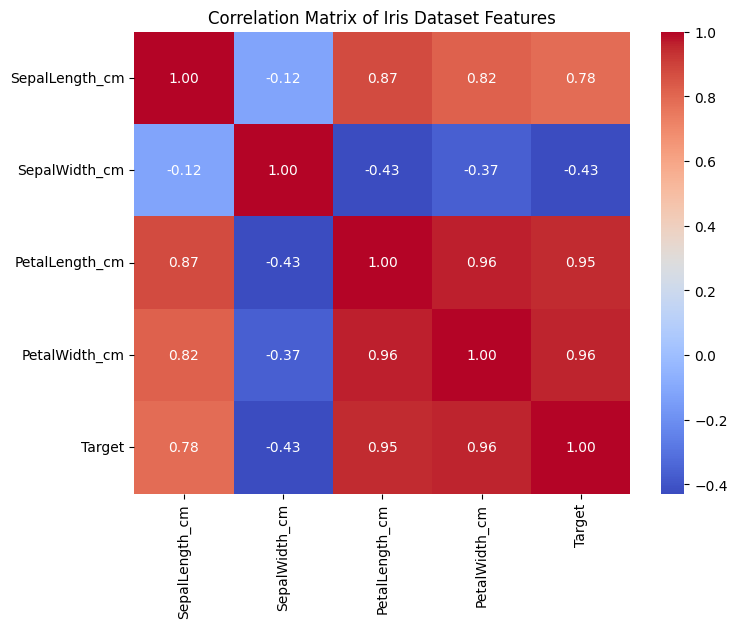


Pair Plots:


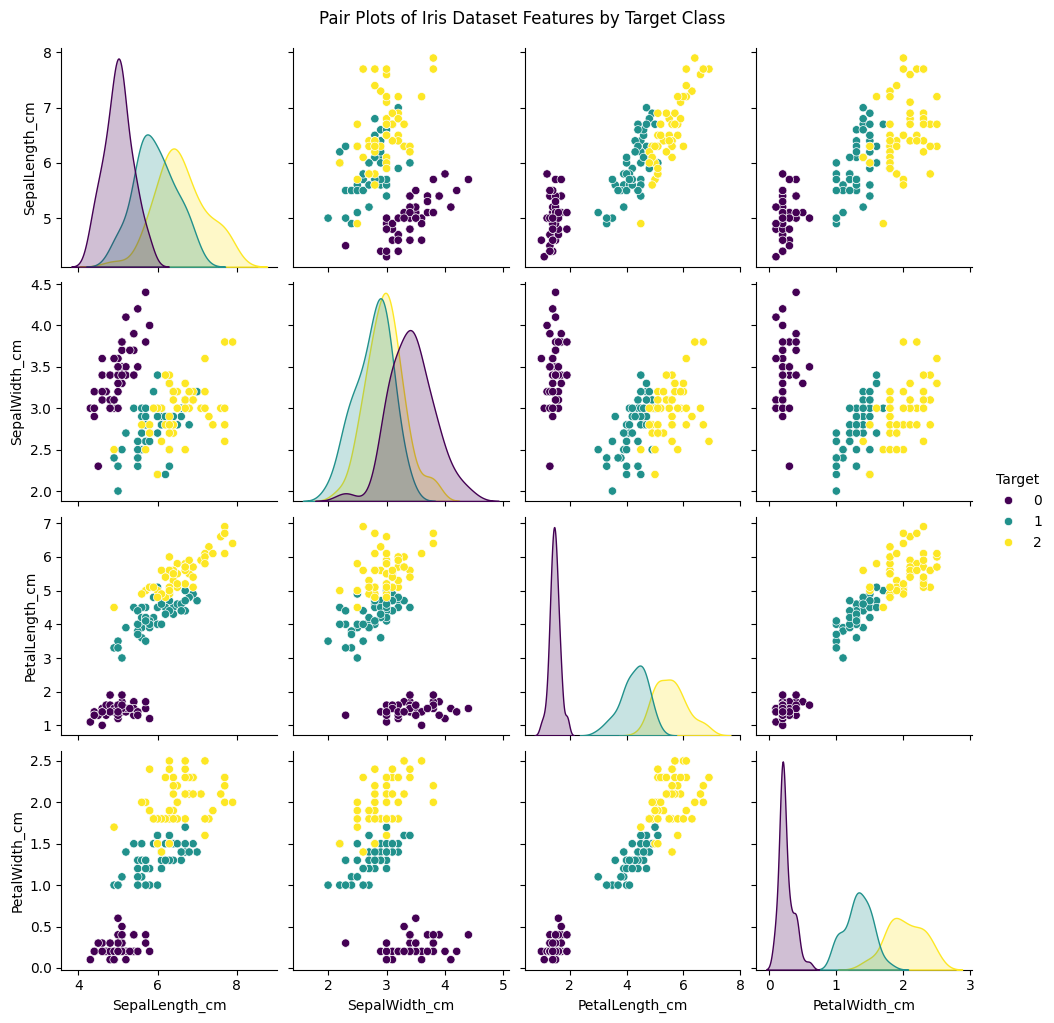

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

# Load the Iris dataset
iris = datasets.load_iris()

# Create a DataFrame from the iris data and feature names (from cell d8fc0937)
df = pd.DataFrame(iris.data, columns=iris.feature_names)
# Add the target column to the DataFrame
df['target'] = iris.target

# Rename columns (from cell SI8sag-4ItiT)
columns_name = ["".join([c.capitalize() for c in cols.split()])  for cols in df.columns ]
columns_name = [col.replace("(" ,"_") for col in columns_name ]
cols = [col.replace(")" ,"") for col in columns_name ]
df.columns = cols

# Display basic descriptive statistics
print("Descriptive Statistics:")
display(df.describe())

# Calculate the correlation matrix
correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Iris Dataset Features')
plt.show()

# Create pair plots to visualize relationships between features and the target
print("\nPair Plots:")
sns.pairplot(df, hue='Target', palette='viridis')
plt.suptitle('Pair Plots of Iris Dataset Features by Target Class', y=1.02) # Adjust suptitle position
plt.show()

6. Encontrar la matrix de correlacion, emplear el metodo corr(), dentro de seaborn buscar el metodo heatmap() para realizar un grafico de la matrix de correlación.

Correlation Matrix:


,SepalLength_cm,SepalWidth_cm,PetalLength_cm,PetalWidth_cm,Target
SepalLength_cm,1.000000,-0.117570,0.871754,0.817941,0.782561
SepalWidth_cm,-0.117570,1.000000,-0.428440,-0.366126,-0.426658
PetalLength_cm,0.871754,-0.428440,1.000000,0.962865,0.949035
PetalWidth_cm,0.817941,-0.366126,0.962865,1.000000,0.956547
Target,0.782561,-0.426658,0.949035,0.956547,1.000000


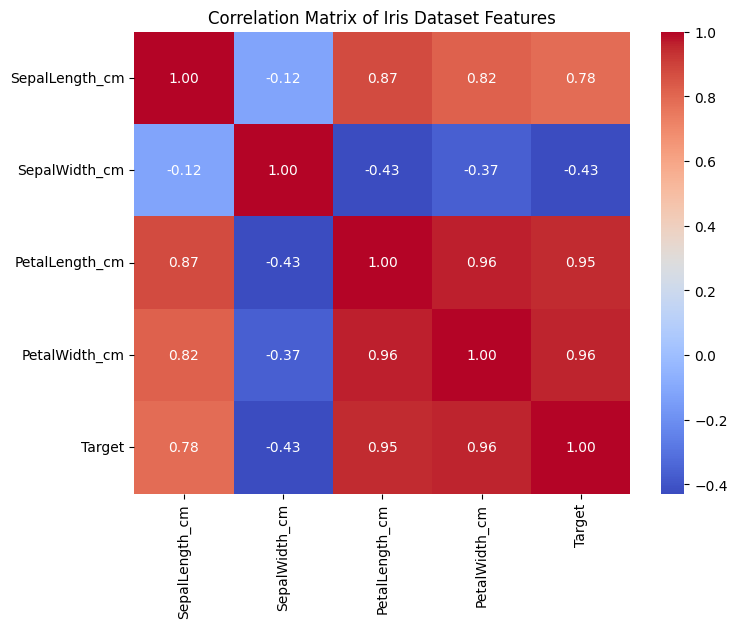

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()
print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Iris Dataset Features')
plt.show()

7. Separar los datos en datos de entramiento y test, prueba la siguiente instruccion:
```
split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]
```
¿Cómo se estan seprando los datos?

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create a StratifiedShuffleSplit object
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# Perform the split
for train_index, test_index in split.split(df, df["Target"]):
  strat_train_set = df.loc[train_index]
  strat_test_set = df.loc[test_index]

print(f"Tamaño del conjunto de entrenamiento: {len(strat_train_set)}")
print(f"Tamaño del conjunto de prueba: {len(strat_test_set)}")

print("\nDistribución de clases en el conjunto completo:")
display(df["Target"].value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de entrenamiento:")
display(strat_train_set["Target"].value_counts(normalize=True))

print("\nDistribución de clases en el conjunto de prueba:")
display(strat_test_set["Target"].value_counts(normalize=True))

print("\n### ¿Cómo se están separando los datos?\n")
print("Los datos se están separando utilizando `StratifiedShuffleSplit`. Este método es particularmente útil cuando se trabaja con datasets donde las clases de la variable objetivo (en este caso, 'Target') están desequilibradas o es importante mantener la proporción de las clases en ambos conjuntos (entrenamiento y prueba).\n")
print("Aquí está cómo funciona:\n")
print("1.  **Estratificación (Stratified)**: En lugar de simplemente dividir los datos aleatoriamente, `StratifiedShuffleSplit` asegura que los conjuntos de entrenamiento y prueba tengan aproximadamente el mismo porcentaje de muestras de cada clase que el dataset original. Por ejemplo, si el dataset tiene un 33.3% de cada tipo de Iris (0, 1, 2), tanto el conjunto de entrenamiento como el de prueba también tendrán un 33.3% de cada tipo.\n")
print("2.  **Aleatorización (Shuffle)**: Además de la estratificación, el método también baraja los datos antes de dividir, lo que ayuda a prevenir cualquier sesgo que pudiera existir si los datos estuvieran ordenados.\n")
print("3.  **Múltiples Splits (n_splits)**: Aunque en este caso `n_splits=1` significa que se realiza una sola división, la funcionalidad permite generar múltiples pares de conjuntos de entrenamiento/prueba independientes con la misma estrategia de estratificación. Esto es útil para validación cruzada.\n")
print("4.  **Tamaño del Test Set (test_size)**: Se ha especificado `test_size=0.2`, lo que significa que el 20% de los datos se asignarán al conjunto de prueba (`strat_test_set`) y el 80% restante al conjunto de entrenamiento (`strat_train_set`).\n")
print("5.  **Semilla Aleatoria (random_state)**: `random_state=42` asegura que la división sea reproducible. Si se ejecuta el código varias veces con el mismo `random_state`, siempre se obtendrán los mismos conjuntos de entrenamiento y prueba.\n")
print("En resumen, esta técnica garantiza que ambos conjuntos sean representativos de la distribución de clases en el dataset completo, lo cual es crucial para entrenar y evaluar modelos de clasificación de manera confiable.")

Tamaño del conjunto de entrenamiento: 120
Tamaño del conjunto de prueba: 30

Distribución de clases en el conjunto completo:


,proportion
Target,
0,0.333333
1,0.333333
2,0.333333



Distribución de clases en el conjunto de entrenamiento:


,proportion
Target,
0,0.333333
2,0.333333
1,0.333333



Distribución de clases en el conjunto de prueba:


,proportion
Target,
0,0.333333
2,0.333333
1,0.333333



### ¿Cómo se están separando los datos?

Los datos se están separando utilizando `StratifiedShuffleSplit`. Este método es particularmente útil cuando se trabaja con datasets donde las clases de la variable objetivo (en este caso, 'Target') están desequilibradas o es importante mantener la proporción de las clases en ambos conjuntos (entrenamiento y prueba).

Aquí está cómo funciona:

1.  **Estratificación (Stratified)**: En lugar de simplemente dividir los datos aleatoriamente, `StratifiedShuffleSplit` asegura que los conjuntos de entrenamiento y prueba tengan aproximadamente el mismo porcentaje de muestras de cada clase que el dataset original. Por ejemplo, si el dataset tiene un 33.3% de cada tipo de Iris (0, 1, 2), tanto el conjunto de entrenamiento como el de prueba también tendrán un 33.3% de cada tipo.

2.  **Aleatorización (Shuffle)**: Además de la estratificación, el método también baraja los datos antes de dividir, lo que ayuda a prevenir cualquier sesgo que pudiera existir s

8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa, emplea la libreria sklearn.


9. Determine  la frontera de clasificación:
```
X_new = np.linspace(-10, 10, 1000).reshape(-1, 1)#Generamos los valores de X_new
prob = log_reg.predict_proba(X_new)

decision_boundary = X_new[prob[:, 0] >= 0.5][0]
decision_boundary
```

10. Encontrar una gráfica de la regresión logística  con los valores de probabilidad

Modelo de Regresión Logística entrenado para clasificar Iris Setosa vs. No-Setosa.
Coeficientes del modelo: 3.68
Intercepto del modelo: -2.53

Frontera de Clasificación (para PetalWidth_cm): 0.00 cm


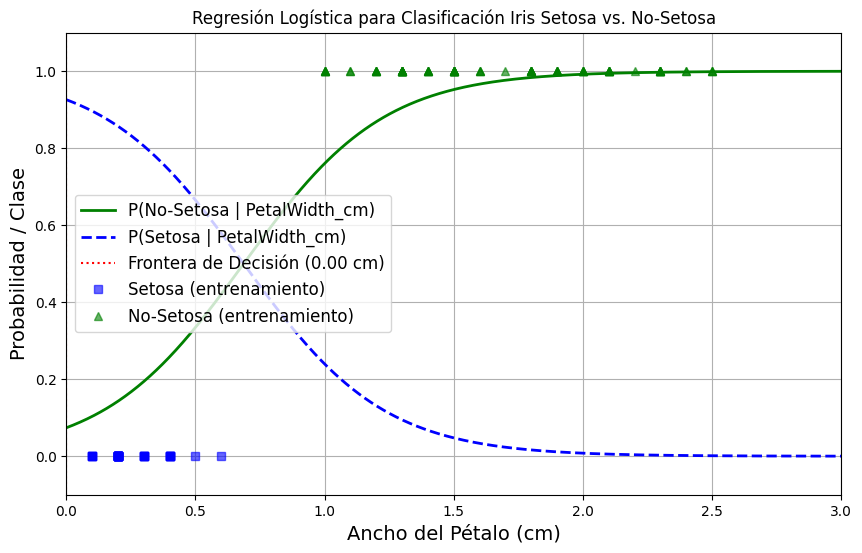

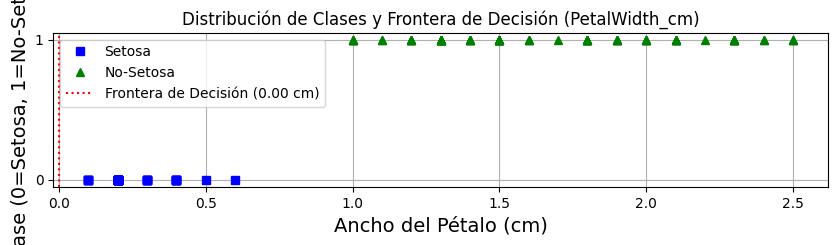

In [18]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 8. Construye un modelo empleando una regresión logística, para clasificar la clase setosa y no setosa

# Prepare data for binary classification (setosa vs. non-setosa)
# We will use 'PetalWidth_cm' as the feature for this example as it's highly correlated
# with the target and allows for a simple 1D decision boundary visualization.

# Features for training and testing
X_train_binary = strat_train_set[['PetalWidth_cm']].values
X_test_binary = strat_test_set[['PetalWidth_cm']].values

# Target: 0 for setosa, 1 for non-setosa (versicolor or virginica)
y_train_binary = (strat_train_set['Target'] != 0).astype(int).values
y_test_binary = (strat_test_set['Target'] != 0).astype(int).values

# Instantiate and train the Logistic Regression model
# Using 'liblinear' solver which is good for small datasets and binary classification
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train_binary, y_train_binary)

print("Modelo de Regresión Logística entrenado para clasificar Iris Setosa vs. No-Setosa.")
print(f"Coeficientes del modelo: {log_reg.coef_[0][0]:.2f}")
print(f"Intercepto del modelo: {log_reg.intercept_[0]:.2f}")

# 9. Determine la frontera de clasificación

# Generamos nuevos valores de X para el rango de PetalWidth_cm para predecir probabilidades y la frontera
X_new = np.linspace(0, 3, 1000).reshape(-1, 1) # Rango de 0 a 3 cm es más adecuado para PetalWidth_cm

# Predecir probabilidades para las nuevas X
prob = log_reg.predict_proba(X_new)

# Determinar la frontera de decisión donde la probabilidad de la clase 0 (Setosa) es >= 0.5
decision_boundary = X_new[prob[:, 0] >= 0.5][0]

print(f"\nFrontera de Clasificación (para PetalWidth_cm): {decision_boundary[0]:.2f} cm")

# Visualización de la frontera de decisión y las probabilidades
plt.figure(figsize=(10, 6))

# Plot de las probabilidades
plt.plot(X_new, prob[:, 1], "g-", linewidth=2, label="P(No-Setosa | PetalWidth_cm)")
plt.plot(X_new, prob[:, 0], "b--", linewidth=2, label="P(Setosa | PetalWidth_cm)")

# Plot de la frontera de decisión
plt.axvline(x=decision_boundary[0], color='r', linestyle=':', label=f'Frontera de Decisión ({decision_boundary[0]:.2f} cm)')

# Plot de los puntos de datos de entrenamiento con sus clases reales
plt.plot(X_train_binary[y_train_binary == 0], np.zeros_like(X_train_binary[y_train_binary == 0]), "bs", label="Setosa (entrenamiento)", alpha=0.6)
plt.plot(X_train_binary[y_train_binary == 1], np.ones_like(X_train_binary[y_train_binary == 1]), "g^", label="No-Setosa (entrenamiento)", alpha=0.6)

plt.xlabel("Ancho del Pétalo (cm)", fontsize=14)
plt.ylabel("Probabilidad / Clase", fontsize=14)
plt.legend(loc="center left", fontsize=12)
plt.axis([0, 3, -0.1, 1.1]) # Ajustar los límites del eje X y Y
plt.title("Regresión Logística para Clasificación Iris Setosa vs. No-Setosa")
plt.grid(True)
plt.show()

# Visualización de la distribución de clases y la frontera
plt.figure(figsize=(10, 2))
plt.plot(X_train_binary[y_train_binary == 0], np.zeros_like(X_train_binary[y_train_binary == 0]), "bs", label="Setosa")
plt.plot(X_train_binary[y_train_binary == 1], np.ones_like(X_train_binary[y_train_binary == 1]), "g^", label="No-Setosa")
plt.axvline(x=decision_boundary[0], color='r', linestyle=':', label=f'Frontera de Decisión ({decision_boundary[0]:.2f} cm)')
plt.xlabel("Ancho del Pétalo (cm)", fontsize=14)
plt.ylabel("Clase (0=Setosa, 1=No-Setosa)", fontsize=14)
plt.yticks([0, 1])
plt.title("Distribución de Clases y Frontera de Decisión (PetalWidth_cm)")
plt.legend()
plt.grid(True)
plt.show()




11. Construye el multiclasificador. Puede emplear los metodos dentro de logistic regresión.


12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica?

In [20]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 11. Construye el multiclasificador.

# Preparar los datos para el multiclasificador
X_train_multi = strat_train_set[['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm']].values
y_train_multi = strat_train_set['Target'].values

X_test_multi = strat_test_set[['SepalLength_cm', 'SepalWidth_cm', 'PetalLength_cm', 'PetalWidth_cm']].values
y_test_multi = strat_test_set['Target'].values

# Inicializar y entrenar el modelo de Regresión Logística para multiclasificación
# 'multi_class' puede ser 'ovr' (One-vs-Rest) o 'multinomial'.
# 'solver' a 'lbfgs' es un buen balance entre rendimiento y robustez para multinomial.
multi_class_log_reg = LogisticRegression(multi_class='ovr', solver='lbfgs', C=10, random_state=42, max_iter=1000)
multi_class_log_reg.fit(X_train_multi, y_train_multi)

print("Modelo de Regresión Logística multiclasificador entrenado.")

# Evaluar el modelo
y_pred_multi = multi_class_log_reg.predict(X_test_multi)
accuracy = accuracy_score(y_test_multi, y_pred_multi)

print(f"Precisión del modelo multiclasificador en el conjunto de prueba: {accuracy:.2f}")

# Mostrar coeficientes e interceptos para cada clase (One-vs-Rest)
print("\nCoeficientes (theta) para cada clase (One-vs-Rest):")
for i, (coef, intercept) in enumerate(zip(multi_class_log_reg.coef_, multi_class_log_reg.intercept_)):
    print(f"Clase {i} (vs todas las demás): Coeficientes={coef.round(2)}, Intercepto={intercept:.2f}")

# 12. Dado X = [4.9,5.0, 1.8, 0.3] asociados a todas las caracteristicas, ¿cuál es la probabilidad de que la flor sea setosa, versicolor o virginica?

X_new_sample = np.array([[4.9, 5.0, 1.8, 0.3]])

# Predecir las probabilidades para el nuevo sample
probabilities = multi_class_log_reg.predict_proba(X_new_sample)

print(f"\nProbabilidades para el nuevo sample {X_new_sample[0]}:")
print(f"  Setosa: {probabilities[0][0]:.4f}")
print(f"  Versicolor: {probabilities[0][1]:.4f}")
print(f"  Virginica: {probabilities[0][2]:.4f}")

# Determinar la clase predicha
predicted_class_index = np.argmax(probabilities)
class_names = iris.target_names # Assuming iris object is available from previous cells
predicted_class_name = class_names[predicted_class_index]

print(f"La clase predicha para la flor es: {predicted_class_name}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Modelo de Regresión Logística multiclasificador entrenado.
Precisión del modelo multiclasificador en el conjunto de prueba: 0.97

Coeficientes (theta) para cada clase (One-vs-Rest):
Clase 0 (vs todas las demás): Coeficientes=[-0.73  1.5  -3.33 -1.57], Intercepto=9.44
Clase 1 (vs todas las demás): Coeficientes=[-0.47 -2.58  1.47 -2.87], Intercepto=7.56
Clase 2 (vs todas las demás): Coeficientes=[-1.24 -1.76  4.88  5.12], Intercepto=-19.72

Probabilidades para el nuevo sample [4.9 5.  1.8 0.3]:
  Setosa: 0.9973
  Versicolor: 0.0027
  Virginica: 0.0000
La clase predicha para la flor es: setosa
